# Определение опечаток

In [23]:
import numpy as np
import pandas as pd
import symspellpy
import nltk
import string
from tqdm import tqdm
from nltk.corpus import stopwords
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка датасета

In [24]:
# schema_name = None
# table_name = None
# columns = None
with open(r'../../data/_46379._54938.txt', 'r', encoding='utf-8') as file:
    line = json.loads(file.readline())
    schema_name = line["schema_name"]
    table_name = line['table_name']
    columns = line['columns']
    column_names = [x[0] for x in columns]
    df = pd.read_json(file, lines=True)
    df.columns= column_names
    
    
print(schema_name)
print(table_name)
print(columns)
print(column_names)
df


    
# df = pd.read_json("data/_46379._54938.txt", lines=True)

_46379
_54938
[['ogc_fid', 'integer'], ['orbis_id', 'double precision'], ['objectid', 'character varying'], ['id', 'double precision'], ['name', 'character varying'], ['doc', 'character varying'], ['area_geom', 'character varying'], ['shape_length', 'character varying'], ['shape_area', 'character varying'], ['fid', 'double precision'], ['fk_oopt', 'double precision'], ['prim', 'character varying']]
['ogc_fid', 'orbis_id', 'objectid', 'id', 'name', 'doc', 'area_geom', 'shape_length', 'shape_area', 'fid', 'fk_oopt', 'prim']


,ogc_fid,orbis_id,objectid,id,name,doc,area_geom,shape_length,shape_area,fid,fk_oopt,prim
0,13,13,None,15,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,13,1000000,None
1,22,22,None,19,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,22,48,None
2,28,28,None,25,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,28,45,Ошибка в координатах ППМ (не хватает координат)
3,31,31,None,32,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,31,90,None
4,2,2,None,2,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,2,46,None
5,19,19,None,29,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,19,90,None
6,46,46,None,46,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,46,63,None
7,29,29,None,26,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,29,45,Ошибка в координатах ППМ (не хватает координат)
8,12,12,None,14,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,12,51,None
9,4,4,None,5,"ООПТ регионального значения ""Памятник природы ...",None,None,None,None,4,23,None


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ogc_fid       46 non-null     int64 
 1   orbis_id      46 non-null     int64 
 2   objectid      46 non-null     object
 3   id            46 non-null     int64 
 4   name          46 non-null     object
 5   doc           46 non-null     object
 6   area_geom     46 non-null     object
 7   shape_length  46 non-null     object
 8   shape_area    46 non-null     object
 9   fid           46 non-null     int64 
 10  fk_oopt       46 non-null     int64 
 11  prim          46 non-null     object
dtypes: int64(5), object(7)
memory usage: 4.4+ KB


In [33]:
df.describe()

,ogc_fid,orbis_id,id,fid,fk_oopt
count,46.000000,46.000000,46.000000,46.000000,46.000000
mean,23.500000,23.500000,23.500000,23.500000,21814.630435
std,13.422618,13.422618,13.422618,13.422618,147430.581038
min,1.000000,1.000000,1.000000,1.000000,19.000000
25%,12.250000,12.250000,12.250000,12.250000,46.250000
50%,23.500000,23.500000,23.500000,23.500000,90.000000
75%,34.750000,34.750000,34.750000,34.750000,99.000000
max,46.000000,46.000000,46.000000,46.000000,1000000.000000


<Figure size 1000x600 with 0 Axes>

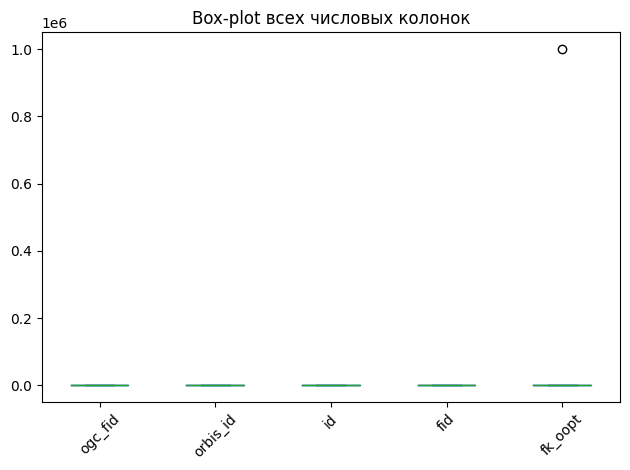

In [26]:
# Box-plot для всех числовых колонок
plt.figure(figsize=(10, 6))
df.plot(kind='box')
plt.title('Box-plot всех числовых колонок')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Анализ выбросов
for column in df.select_dtypes(include=['number']).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Выбросы в колонке '{column}': {len(outliers)}")
    if len(outliers) > 0:
        # print(outliers)
        for _, outlier in outliers.iterrows():
            print(outlier.tolist())

Выбросы в колонке 'ogc_fid': 0
Выбросы в колонке 'orbis_id': 0
Выбросы в колонке 'id': 0
Выбросы в колонке 'fid': 0
Выбросы в колонке 'fk_oopt': 1
   ogc_fid  orbis_id objectid  id  \
0       13        13     None  15   

                                                name   doc area_geom  \
0  ООПТ регионального значения "Памятник природы ...  None      None   

  shape_length shape_area  fid  fk_oopt  prim  
0         None       None   13  1000000  None  


In [97]:
df = pd.read_json("data/data.txt", lines=True)
df

,text,tags,schema_name,table_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876


# 2. Предобработка (очистка) датасета

In [98]:
# Загрузка стоп-слов (один раз при старте)
nltk.download('stopwords')
stop_words = set(stopwords.words('russian')) # Загрузка стоп-слов (один раз при старте)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [99]:
# Функция для очистки текста
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    # Удаление цифр и специальных символов
    text = re.sub(r'\d+', ' ', text)
    # Удаление пунктуации
    # text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.translate(str.maketrans(' ', ' ', string.punctuation))
    # Приведение к нижнему регистру
    text = text.lower()
    # Удаление стоп-слов
    stop_words = set(stopwords.words('russian'))
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

In [100]:
# Функция для обработки чанка с очисткой текста
def process_chunk(chunk):
    """Очистка текста по чанкам"""
    # Очищаем тексты
    cleaned_texts = chunk['text'].apply(clean_text).tolist()
    # Добавляем результаты в чанк
    chunk['cleaned_text'] = cleaned_texts
    return chunk

In [101]:
# Размер чанка (подбирайте под ваши ресурсы)
CHUNK_SIZE = 1000  
# Инициализация прогресс-бара
pbar = tqdm(total=len(df), desc="Обработка датафрейма")
# Обработка по чанкам
results = []
for i in range(0, len(df), CHUNK_SIZE):
    chunk = df.iloc[i:i + CHUNK_SIZE].copy()
    processed_chunk = process_chunk(chunk)
    results.append(processed_chunk)
    pbar.update(len(chunk))
pbar.close()

# Сборка финального датафрейма
final_df = pd.concat(results, ignore_index=True)

Обработка датафрейма: 100%|██████████| 18424/18424 [00:04<00:00, 3946.67it/s]


In [102]:
final_df

,text,tags,schema_name,table_name,cleaned_text
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,часть территории национального парка лосиный о...
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...
...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoзелаоуч комплексныйзаказникзеленоград...
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoюзаоиюао пип битцевский лесучасток jp...
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoюзаоиюао пип битцевский лесучасток jp...
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoзелаоуч комплексныйзаказникзеленоград...


# 3. Находим опечатки в словах без учёта контекста 

In [103]:
# Инициализация
# sym_spell = symspellpy.SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
# оптимальные настройки для русского языка
sym_spell = symspellpy.SymSpell(
    max_dictionary_edit_distance=2,  # Позволяет исправлять 2 ошибки в слове
    prefix_length=6,                 # Оптимально для слов от 5 символов
    count_threshold=1                # Учитывать даже редкие слова
)

# Загрузка словаря (пример для русского)
# Возможно потребуется открыть файл Notepad и перевести в кодировку UTF-8 BOM
# Notepad++ → «Кодировка» → «Преобразовать в UTF-8-BOM» → Сохранить
dict_path = "ru-100k.txt"  # Файл формата: слово\tчастота
sym_spell.load_dictionary(dict_path, term_index=0, count_index=1, encoding='utf-8')

True

In [104]:
# Функция для проверки строки
def check_text_for_typos(text, top_k=3):
    """
    Проверяет текст на опечатки и возвращает предложения исправлений.
    
    Параметры:
        text: строка для проверки
        top_k: количество предлагаемых исправлений
    
    Возвращает:
        dict: {
            'has_typo': bool,
            'corrections': {слово: [исправления]}
        }
    """
    words = text.split()
    result = {'has_typo': False, 'corrections': {}}
    
    for word in words:
        # Игнорируем слова с цифрами/спецсимволами
        if not word.isalpha():
            continue
            
        suggestions = sym_spell.lookup(word, symspellpy.Verbosity.TOP, max_edit_distance=2)
        
        if suggestions and (suggestions[0].term != word.lower()):
            result['has_typo'] = True
            result['corrections'][word] = [sug.term for sug in suggestions[:top_k]]
    
    return result

In [105]:
# Проверка всего датасета
def process_row(row):
    return check_text_for_typos(row['cleaned_text'])



In [106]:
final_df['typo_info'] = final_df.apply(process_row, axis=1)

# Разбиваем результат на отдельные колонки
final_df['has_typo'] = final_df['typo_info'].apply(lambda x: x['has_typo'])
final_df['corrections'] = final_df['typo_info'].apply(lambda x: x['corrections'])

# Отображаем проблемные строки
print(final_df[final_df['has_typo']][['cleaned_text', 'corrections']])

                                            cleaned_text  \
0      часть территории национального парка лосиный о...   
1      часть территории национального парка лосиный о...   
2      часть территории национального парка лосиный о...   
3      часть территории национального парка лосиный о...   
4      часть территории национального парка лосиный о...   
...                                                  ...   
18415  jpg photoюзаоиюао пип битцевский лесучасток jp...   
18416  jpg photoюзаоиюао пип битцевский лесучасток jp...   
18417  jpg photoюзаоиюао пип битцевский лесучасток jp...   
18420  jpg photoюзаоиюао пип битцевский лесучасток jp...   
18421  jpg photoюзаоиюао пип битцевский лесучасток jp...   

                                             corrections  
0      {'лосиный': ['ложный'], 'ппрф': ['при'], 'утве...  
1      {'лосиный': ['ложный'], 'ппм': ['пом'], 'зон':...  
2      {'лосиный': ['ложный'], 'ппм': ['пом'], 'рекре...  
3      {'лосиный': ['ложный'], 'ппм': ['пом

In [107]:
final_df

,text,tags,schema_name,table_name,cleaned_text,typo_info,has_typo,corrections
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,часть территории национального парка лосиный о...,"{'has_typo': True, 'corrections': {'лосиный': ...",True,"{'лосиный': ['ложный'], 'ппрф': ['при'], 'утве..."
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,"{'has_typo': True, 'corrections': {'лосиный': ...",True,"{'лосиный': ['ложный'], 'ппм': ['пом'], 'зон':..."
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,"{'has_typo': True, 'corrections': {'лосиный': ...",True,"{'лосиный': ['ложный'], 'ппм': ['пом'], 'рекре..."
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,"{'has_typo': True, 'corrections': {'лосиный': ...",True,"{'лосиный': ['ложный'], 'ппм': ['пом'], 'рекре..."
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,часть территории национального парка лосиный о...,"{'has_typo': True, 'corrections': {'лосиный': ...",True,"{'лосиный': ['ложный'], 'ппм': ['пом'], 'рекре..."
...,...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoзелаоуч комплексныйзаказникзеленоград...,"{'has_typo': False, 'corrections': {}}",False,{}
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoюзаоиюао пип битцевский лесучасток jp...,"{'has_typo': True, 'corrections': {'пип': ['ти...",True,{'пип': ['тип']}
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoюзаоиюао пип битцевский лесучасток jp...,"{'has_typo': True, 'corrections': {'пип': ['ти...",True,{'пип': ['тип']}
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,jpg photoзелаоуч комплексныйзаказникзеленоград...,"{'has_typo': False, 'corrections': {}}",False,{}


In [118]:
new_words = set()
for row in final_df[final_df['has_typo'] == True]['typo_info']:
    new_words.update(row['corrections'].keys())
with open('new_words.txt', 'w', encoding='utf-8') as f:
    for word in new_words:
        f.write(word + ' 1000\n')


In [95]:
# Тест 1: Слово без ошибок (должно вернуть пустой список)
sym_spell = symspellpy.SymSpell(
    max_dictionary_edit_distance=2,  # Позволяет исправлять 2 ошибки в слове
    prefix_length=3,                 # Оптимально для слов от 5 символов
    count_threshold=1                # Учитывать даже редкие слова
)
# Загрузка словаря (пример для русского)
dict_path = r"D:\Artem\Projects\dam_system\ru-100k.txt"  # Файл формата: слово\tчастота
sym_spell.load_dictionary(dict_path, term_index=0, count_index=1, encoding="utf-8")
result = sym_spell.lookup("толька", symspellpy.Verbosity.ALL, max_edit_distance=2)
l = [sug.term for sug in result]
print(l)


['только', 'толка', 'колька', 'толчка', 'талька', 'полька', 'толика', 'столько', 'тока', 'полка', 'точка', 'молока', 'кольца', 'ольга', 'толпа', 'польша', 'тоска', 'толку', 'толща', 'польза', 'волка', 'толь', 'толк', 'больна', 'толки', 'столика', 'томска', 'тельца', 'галька', 'валька', 'толчки', 'ролика', 'поляка', 'толкая', 'юлька', 'толкал', 'вольта', 'конька', 'тонка', 'дольки', 'ольха', 'горька', 'гольца', 'мольба', 'толику', 'танька', 'алька', 'тальк', 'кольку', 'волчка', 'калька', 'телка']


In [93]:
print("только" in sym_spell.words)  # Должно быть True

False


In [94]:
sym_spell.words

{'Рё': 1954983899,
 'РІ': 1777896533,
 'РЅР°': 757220470,
 'СЃ': 573730702,
 'РЅРµ': 572922286,
 'С‡С‚Рѕ': 423162044,
 'РїРѕ': 371606009,
 'Рє': 290282744,
 'Р°': 280904669,
 'РґР»СЏ': 246215536,
 'РєР°Рє': 244551527,
 'Рѕ': 228326808,
 'РёР·': 212856406,
 'РµРіРѕ': 199670915,
 'РѕС‚': 186911686,
 'РїСЂРё': 178988616,
 'РЅРѕ': 176843721,
 'Р·Р°': 170509258,
 'РѕРЅ': 164510273,
 'СЏ': 157023312,
 'Сѓ': 141115495,
 'Р¶Рµ': 132247321,
 'РІСЃРµ': 131259213,
 'РёР»Рё': 119797047,
 'РёС…': 112369672,
 'РґРѕ': 108670301,
 'С‚Р°Рє': 107533512,
 'С‚РѕР»СЊРєРѕ': 105890951,
 'Р±С‹Р»Рѕ': 104357562,
 'РµРµ': 83253365,
 'РјС‹': 82296922,
 'РІРѕ': 78871081,
 'РѕРЅРё': 78842003,
 'Р±С‹': 78147359,
 'РµС‰Рµ': 72840601,
 'РѕРЅР°': 72308740,
 'РµСЃР»Рё': 70375161,
 'РІСЂРµРјСЏ': 69406295,
 'Р±С‹Р»': 69345894,
 'РєРѕРіРґР°': 64889145,
 'Р±РѕР»РµРµ': 63737041,
 'Р±С‹Р»Рё': 63697786,
 'С‚Р°РєР¶Рµ': 63352916,
 'СѓР¶Рµ': 62412105,
 'Р±С‹С‚СЊ': 61251930,
 'СЃРѕ': 55045013,
 'С‡С‚РѕР±С‹': 54409034,
 'РјРµР¶РґСѓ

In [91]:
# Print out first 5 elements to demonstrate that dictionary is
# successfully loaded
from itertools import islice

print(list(islice(sym_spell.words.items(), 5)))

[]
